In [1]:
from football_dataset_xDiyoFire import *
from utils_xDiyo_wleague import *
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import precision_score, recall_score, mean_squared_error, mean_absolute_error,accuracy_score, f1_score
import random
from torch.profiler import profile, ProfilerActivity
import math
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import colorsys
import copy

In [2]:
random.seed(69)
np.random.seed(69)
torch.manual_seed(69)
if torch.cuda.is_available():
    torch.cuda.manual_seed(69)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
test_names = ['Premier_League_20_21','Premier_League_21_22','Premier_League_22_23','Premier_League_23_24',
            'La_Liga_20_21','La_Liga_21_22','La_Liga_22_23','La_Liga_23_24',
            'La_Liga_2_20_21','La_Liga_2_21_22','La_Liga_2_22_23','La_Liga_2_23_24',
            'Serie_A_20_21','Serie_A_21_22','Serie_A_22_23', 'Serie_A_23_24',
            'Serie_B_20_21','Serie_B_21_22','Serie_B_22_23', 'Serie_B_23_24',
            'Bundesliga_20_21','Bundesliga_21_22','Bundesliga_22_23', 'Bundesliga_23_24',
            'Championship_20_21','Championship_21_22','Championship_22_23','Championship_23_24',
            'Eredivisie_20_21','Eredivisie_21_22','Eredivisie_22_23','Eredivisie_23_24',
            'Premiership_20_21','Premiership_21_22','Premiership_22_23','Premiership_23_24']
train_df,val_df,test_df,league_dict = split_and_merge_leagues(test_names, 0.8, 0.1, 0.1)
atk_headers,def_headers = divide_stats(stat_type='older_stats')
atk_avgs = calculate_mean_std(train_df, atk_headers)
def_avgs = calculate_mean_std(train_df, def_headers)
mu_atk,sigma_atk = extract_averages(atk_avgs, atk_headers)
mu_def,sigma_def = extract_averages(def_avgs, def_headers)
team_names = ['<PAD>']+sorted(train_df['home_team'].unique())
team2id = {name: idx for idx, name in enumerate(team_names)}

In [4]:
# Bundle everything you want to save into a dictionary
save_cache(
    'cached_preprocessing_waverage_heatmap_more.pkl',
    atk_headers=atk_headers,
    def_headers=def_headers,
    atk_avgs=atk_avgs,
    def_avgs=def_avgs,
    mu_atk=mu_atk,
    sigma_atk=sigma_atk,
    mu_def=mu_def,
    sigma_def=sigma_def,
    team_names=team_names,
    team2id=team2id
)

In [4]:
cached_data = load_cache('cached_preprocessing_waverage_heatmap_more.pkl')
atk_headers, def_headers, atk_avgs, def_avgs, mu_atk, sigma_atk, mu_def, sigma_def, team_names, team2id = cached_data['atk_headers'], cached_data['def_headers'], cached_data['atk_avgs'], cached_data['def_avgs'], cached_data['mu_atk'], cached_data['sigma_atk'], cached_data['mu_def'], cached_data['sigma_def'], cached_data['team_names'], cached_data['team2id']   

c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.lo

In [5]:
history_len = 8
n_x,n_y = 18,12

In [5]:
history_len = 8
n_x,n_y = 18,12
flatten_h, reverse_h = False, False
raw_train = FootballDataset(train_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_val = FootballDataset(val_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_test = FootballDataset(test_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')


In [6]:
precompute_data(raw_train, f'data/{history_len}_{n_x}_{n_y}/train', start_idx=0)
precompute_data(raw_val, f'data/{history_len}_{n_x}_{n_y}/val', start_idx=0)
precompute_data(raw_test, f'data/{history_len}_{n_x}_{n_y}/test', start_idx=0)

Preprocessed and saved sample 1/10784
Preprocessed and saved sample 2/10784
Preprocessed and saved sample 3/10784
Preprocessed and saved sample 4/10784
Preprocessed and saved sample 5/10784
Preprocessed and saved sample 6/10784
Preprocessed and saved sample 7/10784
Preprocessed and saved sample 8/10784
Preprocessed and saved sample 9/10784
Preprocessed and saved sample 10/10784
Preprocessed and saved sample 11/10784
Preprocessed and saved sample 12/10784
Preprocessed and saved sample 13/10784
Preprocessed and saved sample 14/10784
Preprocessed and saved sample 15/10784
Preprocessed and saved sample 16/10784
Preprocessed and saved sample 17/10784
Preprocessed and saved sample 18/10784
Preprocessed and saved sample 19/10784
Preprocessed and saved sample 20/10784
Preprocessed and saved sample 21/10784
Preprocessed and saved sample 22/10784
Preprocessed and saved sample 23/10784
Preprocessed and saved sample 24/10784
Preprocessed and saved sample 25/10784
Preprocessed and saved sample 26/1

In [7]:
# Directories for precomputed data
precomputed_dir = f'data/{history_len}_{n_x}_{n_y}'

# Build datasets from precomputed files
train_dataset = build_datasets_from_files(f'{precomputed_dir}/train')
val_dataset = build_datasets_from_files(f'{precomputed_dir}/val')
test_dataset = build_datasets_from_files(f'{precomputed_dir}/test')

In [8]:
# Build dataloaders
batch_size = 1024
train_loader = build_train_loader(train_dataset, batch_size=batch_size)
val_loader = build_val_loader(val_dataset, batch_size=batch_size)
test_loader = build_test_loader(test_dataset, batch_size=batch_size)
data_iter = iter(test_loader)
batch_data = next(data_iter)
edges = extract_edge_info(train_dataset)

c:\Users\luisi\Documents\Programming\Projects\Transformers\Football\football_dataset_xDiyoFire.py:1247: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.

In [9]:
class HeatmapEngineeredFeatureExtractor(nn.Module):
    def __init__(self, n_x, n_y, court_length=1.5, court_width=1.0,
                 scale_pen_home=10.0, scale_def_home=10.0,
                 scale_pen_away=10.0, scale_def_away=10.0, eps=1e-8, device='cuda'):
        """
        Initializes the feature extractor and precomputes the coordinate grids and
        distance weighting tensors for both home and away teams.
        
        Args:
          n_x (int): Number of horizontal cells.
          n_y (int): Number of vertical cells.
          court_length (float): Total length of the field along x.
          court_width (float): Total width of the field along y.
          scale_pen_home, scale_def_home: Scaling factors for home penetration and defense.
          scale_pen_away, scale_def_away: Scaling factors for away penetration and defense.
          eps (float): Small constant for numerical stability.
        """
        super().__init__()
        self.n_x = n_x
        self.n_y = n_y
        self.court_length = court_length
        self.court_width = court_width
        self.scale_pen_home = scale_pen_home
        self.scale_def_home = scale_def_home
        self.scale_pen_away = scale_pen_away
        self.scale_def_away = scale_def_away
        self.eps = eps
        self.device = device

        # Compute coordinate grids and register as buffers (shape: (n_y, n_x))
        X, Y = self.compute_coordinate_grids(n_x, n_y, court_length, court_width)
        self.register_buffer("X", X)  
        self.register_buffer("Y", Y)  

        # Precompute weighting tensors:
        home_pen_weight, home_def_weight = self.create_distance_weighting_tensors_home(n_x, n_y, court_length, court_width)
        #self.home_pen_weight.to(self.device)
        #self.home_def_weight.to(self.device)

        
        away_pen_weight, away_def_weight = self.create_distance_weighting_tensors_away(n_x, n_y, court_length, court_width)
        #self.away_pen_weight.to(self.device)
        #self.away_def_weight.to(self.device)

        self.register_buffer("home_pen_weight", home_pen_weight)
        self.register_buffer("home_def_weight", home_def_weight)        
        self.register_buffer("away_pen_weight", away_pen_weight)
        self.register_buffer("away_def_weight", away_def_weight)


    
    @staticmethod
    def compute_coordinate_grids(n_x, n_y, court_length=1.5, court_width=1.0):
        cell_width = court_length / n_x
        cell_height = court_width / n_y
        x_coords = (torch.arange(n_x, dtype=torch.float32) + 0.5) * cell_width
        y_coords = (torch.arange(n_y, dtype=torch.float32) + 0.5) * cell_height
        # Using 'ij' indexing: result shape is (n_y, n_x)
        Y, X = torch.meshgrid(y_coords, x_coords, indexing='ij')
        return X, Y

    def create_distance_weighting_tensors_home(self, n_x, n_y, court_length=1.5, court_width=1.0):
        X, Y = self.compute_coordinate_grids(n_x, n_y, court_length, court_width)
        home_goal = torch.tensor([0.0, court_width/2.0], dtype=torch.float32, device=X.device)
        center = torch.tensor([court_length/2.0, court_width/2.0], dtype=torch.float32, device=X.device)
        coords = torch.stack([X, Y], dim=-1)
        distances_goal = torch.norm(coords - home_goal, dim=-1)
        distances_center = torch.norm(coords - center, dim=-1)
        #enemy_mask = (X > (court_length / 2)).float()
        #home_mask = (X <= (court_length / 2)).float()
        penetration_weight = distances_goal# * enemy_mask
        defense_weight = distances_center# * home_mask
        return penetration_weight, defense_weight

    def create_distance_weighting_tensors_away(self, n_x, n_y, court_length=1.5, court_width=1.0):
        X, Y = self.compute_coordinate_grids(n_x, n_y, court_length, court_width)
        away_goal = torch.tensor([court_length, court_width/2.0], dtype=torch.float32, device=X.device)
        center = torch.tensor([court_length/2.0, court_width/2.0], dtype=torch.float32, device=X.device)
        coords = torch.stack([X, Y], dim=-1)
        distances_goal = torch.norm(coords - away_goal, dim=-1)
        distances_center = torch.norm(coords - center, dim=-1)
        #opponent_mask = (X < (court_length / 2)).float()
        #own_mask = (X >= (court_length / 2)).float()
        penetration_weight = distances_goal# * opponent_mask
        defense_weight = distances_center# * own_mask
        return penetration_weight, defense_weight

    def forward(self, home_heatmaps, away_heatmaps):
        """
        Computes engineered features for every match and returns a concatenated feature vector.
        
        Args:
          home_heatmaps (torch.Tensor): Tensor of shape (B, M, n_y, n_x) for home team densities.
          away_heatmaps (torch.Tensor): Tensor of shape (B, M, n_y, n_x) for away team densities.
          
        Returns:
          combined_features (torch.Tensor): Tensor of shape (B, M, 2*(4+n_x+n_y)), obtained by concatenating
             home and away engineered feature vectors for each match.
        """
        B, M, n_y, n_x = home_heatmaps.shape
        device = home_heatmaps.device

        # Flatten batch and match dims: (B*M, n_y, n_x)
        home_flat = home_heatmaps.view(B * M, n_y, n_x).float()
        away_flat = away_heatmaps.view(B * M, n_y, n_x).float()
        # For the away side, flip both spatial dimensions for proper orientation.
        #away_flat = torch.flip(away_flat, dims=[1, 2])
        
        # --- Home engineered features ---
        diff_pen_home = F.relu(home_flat - away_flat)
        diff_pen_home.to(device)
        diff_def_home = 0.005 * torch.exp(-200 * F.relu(away_flat - home_flat))
        diff_def_home.to(device)

        weighted_pen_home = diff_pen_home * self.home_pen_weight  # broadcasts to (B*M, n_y, n_x)
        weighted_def_home = diff_def_home * self.home_def_weight

        home_pen_score = self.scale_pen_home * weighted_pen_home.sum(dim=(1,2))  # (B*M,)
        home_def_score = self.scale_def_home * weighted_def_home.sum(dim=(1,2))
        
        home_marginal_x = home_flat.sum(dim=1)  # (B*M, n_x)
        home_marginal_y = home_flat.sum(dim=2)  # (B*M, n_y)
        home_marginal_x = home_marginal_x / (home_marginal_x.sum(dim=1, keepdim=True) + self.eps)
        home_marginal_y = home_marginal_y / (home_marginal_y.sum(dim=1, keepdim=True) + self.eps)
        
        home_total = home_flat.sum(dim=(1,2)) + self.eps
        home_center_x = (home_flat * self.X).sum(dim=(1,2)) / home_total
        home_center_y = (home_flat * self.Y).sum(dim=(1,2)) / home_total
        
        # Concatenate home features into vector: shape (B*M, 4+n_x+n_y)
        feat_home = torch.cat([     # (B*M, 1)
            home_center_x.unsqueeze(1),      # (B*M, 1)
            home_center_y.unsqueeze(1),      # (B*M, 1)
            home_marginal_x,                 # (B*M, n_x)
            home_marginal_y                  # (B*M, n_y)
        ], dim=1)
        
        # --- Away engineered features ---
        diff_pen_away = F.relu(away_flat - home_flat)
        diff_pen_away.to(device)
        diff_def_away = 0.005 * torch.exp(-200 * F.relu(home_flat - away_flat))
        diff_def_away.to(device)
        weighted_pen_away = diff_pen_away * self.away_pen_weight
        weighted_def_away = diff_def_away * self.away_def_weight
        away_pen_score = self.scale_pen_away * weighted_pen_away.sum(dim=(1,2))
        away_def_score = self.scale_def_away * weighted_def_away.sum(dim=(1,2))
        
        away_marginal_x = away_flat.sum(dim=1)  # (B*M, n_x)
        away_marginal_y = away_flat.sum(dim=2)  # (B*M, n_y)
        away_marginal_x = away_marginal_x / (away_marginal_x.sum(dim=1, keepdim=True) + self.eps)
        away_marginal_y = away_marginal_y / (away_marginal_y.sum(dim=1, keepdim=True) + self.eps)
        
        away_total = away_flat.sum(dim=(1,2)) + self.eps
        away_center_x = (away_flat * self.X).sum(dim=(1,2)) / away_total
        away_center_y = (away_flat * self.Y).sum(dim=(1,2)) / away_total
        
        feat_away = torch.cat([
            away_center_x.unsqueeze(1),
            away_center_y.unsqueeze(1),
            away_marginal_x,
            away_marginal_y
        ], dim=1)  # (B*M, 4+n_x+n_y)
        
        # Concatenate home and away engineered features:
        combined_features = torch.cat([feat_home, feat_away], dim=1)  # shape: (B*M, 2*(4+n_x+n_y))
        combined_features = combined_features.view(B, M, -1)  # shape: (B, M, 2*(4+n_x+n_y))
        return combined_features

In [117]:
n_x, n_y = 18, 12
extractor = HeatmapEngineeredFeatureExtractor(n_x, n_y, court_length=1.5, court_width=1.0,
                                                scale_pen_home=10.0, scale_def_home=10.0,
                                                scale_pen_away=10.0, scale_def_away=10.0)

In [10]:
team_player_tensor = batch_data['home_team_player_heatmap_sequence']
enemy_player_tensor = batch_data['home_enemy_player_heatmap_sequence']
mask =batch_data['home_team_valid_mask']

In [75]:
features = extractor(team_player_tensor, enemy_player_tensor)

In [78]:
features

tensor([[[0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [1.2179, 2.2040, 0.6919,  ..., 0.0856, 0.1070, 0.1056]],

        [[0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.9548, 2.3231, 0.7286,  ..., 0.1007, 0.1020, 0.0958]],

        [[0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 2.6096, 0.0000,  ..., 0.0000, 0.0000, 0.

In [85]:
len(features)

583

In [11]:
# -----------------------------
# 1. HeatmapEngineeredFeatureExtractor (Reused)


# -----------------------------
# 2. SimpleHeatmapCNN (Unchanged)
class SimpleHeatmapCNN(nn.Module):
    def __init__(self, n_y, n_x, output_dim=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        conv_out_dim = 16 * (n_y // 4) * (n_x // 4)
        self.fc = nn.Linear(conv_out_dim, output_dim)
    
    def forward(self, x):
        out = self.conv(x)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# -----------------------------
# 3. CombinedConditioningExtractor (Updated)
class CombinedConditioningExtractor(nn.Module):
    def __init__(self, n_x, n_y, court_length=1.5, court_width=1.0,
                 scale_pen_home=10.0, scale_def_home=10.0, scale_pen_away=10.0, scale_def_away=10.0,
                 engineered_feature_dim=None, cnn_hidden_dim=32, cond_dim=20, device = 'cuda'):
        """
        Extracts a conditioning vector from the pair of heatmaps.
        Uses:
          - HeatmapEngineeredFeatureExtractor to compute engineered features for both sides.
            * For home features, call with (home_heatmap, away_heatmap).
            * For away features, call with (away_heatmap, home_heatmap).
          - SimpleHeatmapCNN to compute a hidden representation from the stacked heatmaps.
        The outputs are concatenated and mapped via a fully-connected layer to produce a final conditioning vector.
        """
        super().__init__()
        if engineered_feature_dim is None:
            engineered_feature_dim =  n_x + n_y + 2  # dimension for one side
        # We'll output engineered features for both sides, so final engineered feature vector dimension is doubled.
        self.engineered_feature_dim = engineered_feature_dim * 2
        self.engineered_feature_extractor = HeatmapEngineeredFeatureExtractor(n_x, n_y, court_length, court_width,
                                                                               scale_pen_home, scale_def_home,scale_pen_away=10.0, 
                                                                               scale_def_away=10.0, eps=1e-8, device=device)
        self.cnn_encoder = SimpleHeatmapCNN(n_y, n_x, output_dim=cnn_hidden_dim)
        self.fc = nn.Linear(self.engineered_feature_dim + cnn_hidden_dim, cond_dim)
    
    def forward(self, home_heatmap, away_heatmap):
        """
        Args:
          home_heatmap, away_heatmap: Tensors of shape (B, 1, n_y, n_x)
        Process:
          - For each sample, compute:
              feature_labels_home: engineered features from (home_heatmap, away_heatmap)
              feature_labels_away: engineered features from (away_heatmap, home_heatmap)
            Concatenate these to form a vector of dimension 2*(4+n_x+n_y).
          - Process the two heatmaps through the CNN (stacked along channel dim) to obtain a hidden vector.
          - Concatenate both and map via an FC layer to obtain the final conditioning vector.
        Returns:
          cond: Tensor of shape (B, cond_dim)
          feature_labels: Tensor of shape (B, 2*(4+n_x+n_y)) (concatenation of home and away engineered features)
        """
        B = home_heatmap.size(0)
        feature_labels = self.engineered_feature_extractor(home_heatmap, away_heatmap).squeeze(1)  # shape: (B, 2*(4+n_x+n_y))
        
        cnn_input = torch.cat([home_heatmap, away_heatmap], dim=1)  # shape: (B, 2, n_y, n_x)
        cnn_hidden = self.cnn_encoder(cnn_input)  # shape: (B, cnn_hidden_dim)
        cond_in = torch.cat([feature_labels, cnn_hidden], dim=1)  # shape: (B, 2*(4+n_x+n_y)+cnn_hidden_dim)
        cond = self.fc(cond_in)  # shape: (B, cond_dim)
        return cond, feature_labels

# -----------------------------
# 4. DualHeatmapCVAE (Unchanged)
class DualHeatmapCVAE(nn.Module):
    def __init__(self, cond_dim, latent_dim, n_y, n_x):
        super().__init__()
        self.cond_dim = cond_dim
        self.latent_dim = latent_dim
        self.n_y = n_y
        self.n_x = n_x
        self.heatmap_size = n_y * n_x
        
        self.encoder = nn.Sequential(
            nn.Linear(cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim * 2)
        )
        decoder_input_dim = latent_dim + cond_dim
        self.home_decoder = nn.Sequential(
            nn.Linear(decoder_input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, self.heatmap_size),
            nn.Sigmoid()
        )
        self.away_decoder = nn.Sequential(
            nn.Linear(decoder_input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, self.heatmap_size),
            nn.Sigmoid()
        )
    
    def encode(self, cond):
        stats = self.encoder(cond)  # shape: (B, latent_dim*2)
        mu, logvar = stats.chunk(2, dim=1)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, cond):
        z_cond = torch.cat([z, cond], dim=1)
        home_flat = self.home_decoder(z_cond)
        away_flat = self.away_decoder(z_cond)
        home_heatmap = home_flat.view(-1, self.n_y, self.n_x)
        away_heatmap = away_flat.view(-1, self.n_y, self.n_x)
        return home_heatmap, away_heatmap
    
    def forward(self, cond):
        mu, logvar = self.encode(cond)
        z = self.reparameterize(mu, logvar)
        home_heatmap, away_heatmap = self.decode(z, cond)
        return home_heatmap, away_heatmap, mu, logvar

# -----------------------------
# 5. CombinedHeatmapCVAEModel with Auxiliary Outputs.
class CombinedHeatmapCVAEModel(nn.Module):
    def __init__(self, n_x, n_y, court_length=1.5, court_width=1.0,
                 scale_pen_home=10.0, scale_def_home=10.0, scale_pen_away=10.0, scale_def_away=10.0,
                 engineered_feature_dim=None, cnn_hidden_dim=32, cond_dim=20, latent_dim=16, device = 'cuda'):
        super().__init__()
        if engineered_feature_dim is None:
            engineered_feature_dim = 2 + n_x + n_y
        self.conditioning_extractor = CombinedConditioningExtractor(n_x, n_y, court_length, court_width,
                                                                     scale_pen_home, scale_def_home,
                                                                     scale_pen_away, scale_def_away,
                                                                     engineered_feature_dim, cnn_hidden_dim, cond_dim, device)
        self.cvae = DualHeatmapCVAE(cond_dim, latent_dim, n_y, n_x)
        # We'll reuse the engineered feature extractor from the conditioning extractor
        # to compute auxiliary labels.
        self.engineered_feature_extractor = self.conditioning_extractor.engineered_feature_extractor

    def forward(self, home_heatmap, away_heatmap):
        """
        Args:
          home_heatmap, away_heatmap: Tensors of shape (B, 1, n_y, n_x).
        Returns:
          home_pred, away_pred, mu, logvar, feature_labels, pred_labels_home, pred_labels_away
            - feature_labels: Concatenated engineered features computed from the raw inputs,
                              shape (B, 2*(4+n_x+n_y)) with home features first and away features second.
            - pred_labels_home: Engineered features computed from predicted heatmaps for the home side.
            - pred_labels_away: Engineered features computed from predicted heatmaps for the away side.
        """
        B = home_heatmap.size(0)
        home_heatmap = home_heatmap[:,-1,:,:].unsqueeze(1)
        torch.flip(away_heatmap, dims=[2,3])
        away_heatmap = away_heatmap[:,-1,:,:].unsqueeze(1)
        # Compute conditioning vector and engineered features from input.
        cond, feature_labels = self.conditioning_extractor(home_heatmap, away_heatmap)  
        # feature_labels shape: (B, 2*(4+n_x+n_y)); first half for home, second half for away.
        
        # Run CVAE.
        home_pred, away_pred, mu, logvar = self.cvae(cond)
        
        # Compute predicted engineered features for each sample.
        pred_labels = self.engineered_feature_extractor(home_pred.unsqueeze(1), away_pred.unsqueeze(1)).squeeze(1)

        return home_pred, away_pred, mu, logvar, feature_labels, pred_labels

In [12]:
    
model = CombinedHeatmapCVAEModel(n_x, n_y, court_length=1.5, court_width=1.0,
                                    scale_pen_home=10.0, scale_def_home=10.0,
                                    scale_pen_away=10.0, scale_def_away=10.0,
                                    engineered_feature_dim=None, cnn_hidden_dim=32,
                                    cond_dim=20, latent_dim=16)
#home_pred, away_pred, mu, logvar, feature_labels, pred_labels = model(team_player_tensor, enemy_player_tensor)
#print("Predicted home heatmap shape:", home_pred.shape)  # Expected: (B, n_y, n_x)
#print("Feature labels shape:", feature_labels.shape)      # Expected: (B, engineered_feature_dim)
#print("Predicted labels shape:", pred_labels.shape)         # Expected: (B, engineered_feature_dim)
#model.load_state_dict(torch.load("combined_heatmap_cvae_best.pth"))

In [9]:
def loss_function(home_pred, away_pred, home_gt, away_gt, mu, logvar, feature_labels, pred_labels, aux_weight=1.0):
    """
    Computes the total loss.
    - Reconstruction loss for home and away heatmaps (MSE).
    - KL divergence for the latent space.
    - Auxiliary loss: MSE between engineered feature vectors (feature_labels and pred_labels).
    
    Args:
    home_pred, away_pred (torch.Tensor): Predicted heatmaps (B, n_y, n_x).
    home_gt, away_gt (torch.Tensor): Ground-truth heatmaps, same shape.
    mu, logvar (torch.Tensor): Latent distribution parameters (B, latent_dim).
    feature_labels, pred_labels (torch.Tensor): Engineered feature vectors computed from input and predicted heatmaps (B, engineered_feature_dim).
    aux_weight (float): Weight for the auxiliary loss.
    
    Returns:
    total_loss (torch.Tensor), recon_loss, kl_loss, aux_loss (all scalars).
    """
    # Reconstruction loss: Mean Squared Error for both home and away.
    recon_loss_home = F.mse_loss(home_pred, home_gt, reduction='sum')
    recon_loss_away = F.mse_loss(away_pred, away_gt, reduction='sum')
    recon_loss = recon_loss_home + recon_loss_away

    # KL Divergence loss.
    # KL( N(mu, sigma) || N(0, I) )
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Auxiliary loss: MSE between input engineered features and predicted features.
    aux_loss = F.mse_loss(pred_labels, feature_labels, reduction='sum')
    # Normalization loss
    norm_loss = F.mse_loss(home_pred.sum(dim=[1,2]), torch.ones_like(home_pred.sum(dim=[1,2]), device=device), reduction='sum')+\
                F.mse_loss(away_pred.sum(dim=[1,2]), torch.ones_like(away_pred.sum(dim=[1,2]), device=device), reduction='sum')
    
    total_loss = recon_loss + kl_loss + aux_weight * aux_loss + norm_loss
    return total_loss, recon_loss, kl_loss, aux_loss, norm_loss

# Training loop function.
def train_model(model, train_loader, val_loader, num_epochs, device,
                aux_weight=1.0, patience=5, scheduler_patience=2):
    """
    Trains the model with a scheduler and early stopping.
    
    Args:
    model (nn.Module): The CombinedHeatmapCVAEModel instance.
    train_loader, val_loader: DataLoader objects providing training and validation batches.
    Each batch should be a tuple: (home_heatmaps, away_heatmaps) of shape (B, 1, n_y, n_x).
    num_epochs (int): Maximum number of epochs.
    device: Device to train on (e.g., 'cuda' or 'cpu').
    aux_weight (float): Weight for the auxiliary loss term.
    patience (int): Number of epochs with no improvement before early stopping.
    scheduler_patience (int): Patience for the ReduceLROnPlateau scheduler.
    
    Returns:
    best_model: The best model (state dict loaded).
    history: Dictionary with training and validation losses per epoch.
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    # Scheduler reduces LR if validation loss does not improve.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, verbose=True)
    
    best_val_loss = np.inf
    best_model_state = None
    epochs_no_improve = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        running_aux = 0.0
        running_norm = 0.0
        
        for batch in train_loader:
            home_hm = batch['home_team_player_heatmap_sequence']
            away_hm = batch['away_enemy_player_heatmap_sequence']
            home_hm = home_hm.to(device)  # shape: (B, 1, n_y, n_x)
            away_hm = away_hm.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass: 
            # The model returns predicted heatmaps and auxiliary engineered features.
            home_pred, away_pred, mu, logvar, feature_labels, pred_labels = model(home_hm, away_hm)
            # For CVAE, typically ground truth equals the input.
            loss, recon_loss, kl_loss, aux_loss, norm_loss = loss_function(home_pred, away_pred,
                                                                home_hm[:,-1,:,:], away_hm[:,-1,:,:],
                                                                mu, logvar,
                                                                feature_labels, pred_labels,
                                                                aux_weight=aux_weight)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()
            running_aux += aux_loss.item()
            running_norm += norm_loss.item()
        
        avg_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        # Validation phase.
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                home_hm = batch['home_team_player_heatmap_sequence']
                away_hm = batch['away_enemy_player_heatmap_sequence']
                home_hm = home_hm.to(device)  # shape: (B, 1, n_y, n_x)
                away_hm = away_hm.to(device)
                
                home_pred, away_pred, mu, logvar, feature_labels, pred_labels = model(home_hm, away_hm)
                loss, _, _, _, _ = loss_function(home_pred, away_pred,
                                            home_hm[:,-1,:,:], away_hm[:,-1,:,:],
                                            mu, logvar,
                                            feature_labels, pred_labels,
                                            aux_weight=aux_weight)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        scheduler.step(avg_val_loss)
        
        # Early stopping: if validation loss does not improve.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            print("Early stopping triggered!")
            break
            
    # Load best model state.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Plot training and validation losses.
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.show()
    
    history = {'train_losses': train_losses, 'val_losses': val_losses}
    return model, history

c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/200] - Train Loss: 22773.4797 | Val Loss: 22610.7292
Epoch [2/200] - Train Loss: 22514.3581 | Val Loss: 22345.3177
Epoch [3/200] - Train Loss: 22261.8263 | Val Loss: 22090.7326
Epoch [4/200] - Train Loss: 22006.4693 | Val Loss: 21849.7517
Epoch [5/200] - Train Loss: 21744.9944 | Val Loss: 21600.5417
Epoch [6/200] - Train Loss: 21480.2247 | Val Loss: 21312.9583
Epoch [7/200] - Train Loss: 21212.7725 | Val Loss: 21014.1007
Epoch [8/200] - Train Loss: 20937.4254 | Val Loss: 20779.8819
Epoch [9/200] - Train Loss: 20650.0569 | Val Loss: 20456.7118
Epoch [10/200] - Train Loss: 20364.1349 | Val Loss: 20163.6389
Epoch [11/200] - Train Loss: 20043.3934 | Val Loss: 19870.4983
Epoch [12/200] - Train Loss: 19714.3588 | Val Loss: 19527.9601
Epoch [13/200] - Train Loss: 19388.5398 | Val Loss: 19142.7708
Epoch [14/200] - Train Loss: 19000.1964 | Val Loss: 18727.7031
Epoch [15/200] - Train Loss: 18607.0212 | Val Loss: 18318.7188
Epoch [16/200] - Train Loss: 18163.2699 | Val Loss: 17865.9010
E

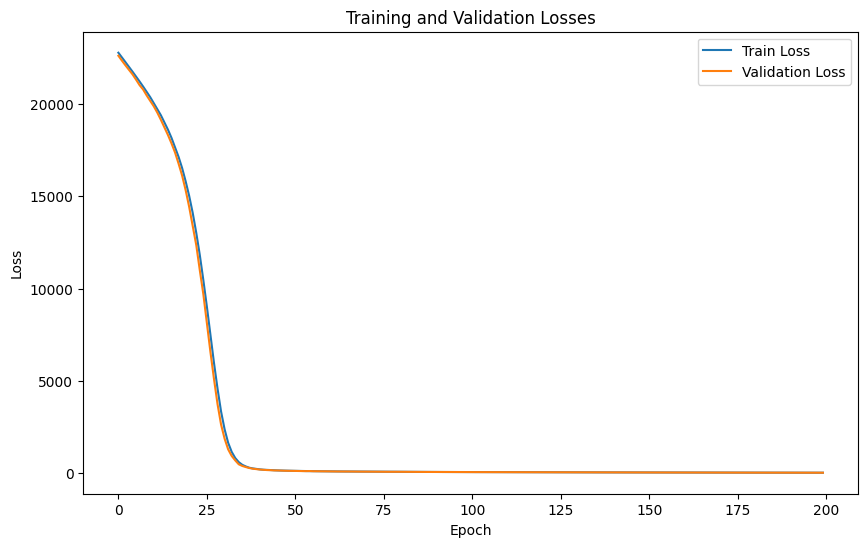

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Train the model.
trained_model, history = train_model(model, train_loader, val_loader, num_epochs=200, device='cuda',
                                        aux_weight=1.0, patience=5, scheduler_patience=3)

# Optionally, save the best model.
torch.save(trained_model.state_dict(), "combined_heatmap_cvae_best_no_mask.pth")

In [1]:
# Assuming your model class is CombinedHeatmapCVAEModel and has been defined and trained.
# Also assuming your best model state was saved in "combined_heatmap_cvae_best.pth"

# 1. Load the model.
#n_x, n_y = 18, 12
#model = CombinedHeatmapCVAEModel(n_x, n_y, court_length=1.5, court_width=1.0,
#                                 scale_pen_home=10.0, scale_def_home=10.0,
#                                 scale_pen_away=10.0, scale_def_away=10.0,
#                                 engineered_feature_dim=None, cnn_hidden_dim=32,
#                                 cond_dim=20, latent_dim=16)
#model.load_state_dict(torch.load("combined_heatmap_cvae_best.pth"))
trained_model.eval()  # Set to evaluation mode.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained_model.to(device)

# 2. Prepare your test data.
# For illustration, assume we have test tensors home_test and away_test of shape (N, 1, n_y, n_x).
# Replace these with your actual test set.


# 3. Inference.
all_home_preds = []
all_away_preds = []
all_mu = []
all_logvar = []
all_feature_labels = []
all_pred_labels = []
all_home_gt = []
all_away_gt = []

with torch.no_grad():
    for batch in test_loader:
        home_hm = batch['home_team_player_heatmap_sequence']
        away_hm = batch['home_enemy_player_heatmap_sequence']
        home_hm = home_hm.to(device)  # shape: (B, 1, n_y, n_x)
        away_hm = away_hm.to(device)
        # For test time, you might want to use the mean of the latent distribution.
        # One way is to simply run the forward pass as usual.
        home_pred, away_pred, mu, logvar, feature_labels, pred_labels = trained_model(home_hm, away_hm)
        all_home_preds.append(home_pred.cpu())
        all_away_preds.append(away_pred.cpu())
        all_mu.append(mu.cpu())
        all_logvar.append(logvar.cpu())
        all_feature_labels.append(feature_labels.cpu())
        all_pred_labels.append(pred_labels.cpu())
        all_home_gt.append(home_hm[:,-1,:,:].cpu())
        all_away_gt.append(torch.flip(away_hm[:,-1,:,:], dims=(1,2)).cpu())
        #all_away_gt.append(away_hm[:,-1,:,:].cpu())

# Concatenate results.
all_home_gt = torch.cat(all_home_gt, dim=0)
all_away_gt = torch.cat(all_away_gt, dim=0)
all_home_preds = torch.cat(all_home_preds, dim=0)
all_away_preds = torch.cat(all_away_preds, dim=0)
all_mu = torch.cat(all_mu, dim=0)
all_logvar = torch.cat(all_logvar, dim=0)
all_feature_labels = torch.cat(all_feature_labels, dim=0)
all_pred_labels = torch.cat(all_pred_labels, dim=0)


# 4. Post-processing: (for example, you can now visualize a predicted heatmap)
import matplotlib.pyplot as plt
# Visualize the first test sample's predicted home heatmap.
plt.figure(figsize=(6, 4))
plt.imshow(all_home_preds[0].squeeze(), cmap='viridis', origin='lower')
plt.title("Predicted Home Heatmap (Test Sample 1)")
plt.colorbar()
plt.show()

# Visualize the first test sample's predicted home heatmap.
plt.figure(figsize=(6, 4))
plt.imshow(all_home_gt[0].squeeze(), cmap='viridis', origin='lower')
plt.title("Predicted Home Heatmap (Test Sample 1)")
plt.colorbar()
plt.show()


NameError: name 'trained_model' is not defined

tensor(3.4996)


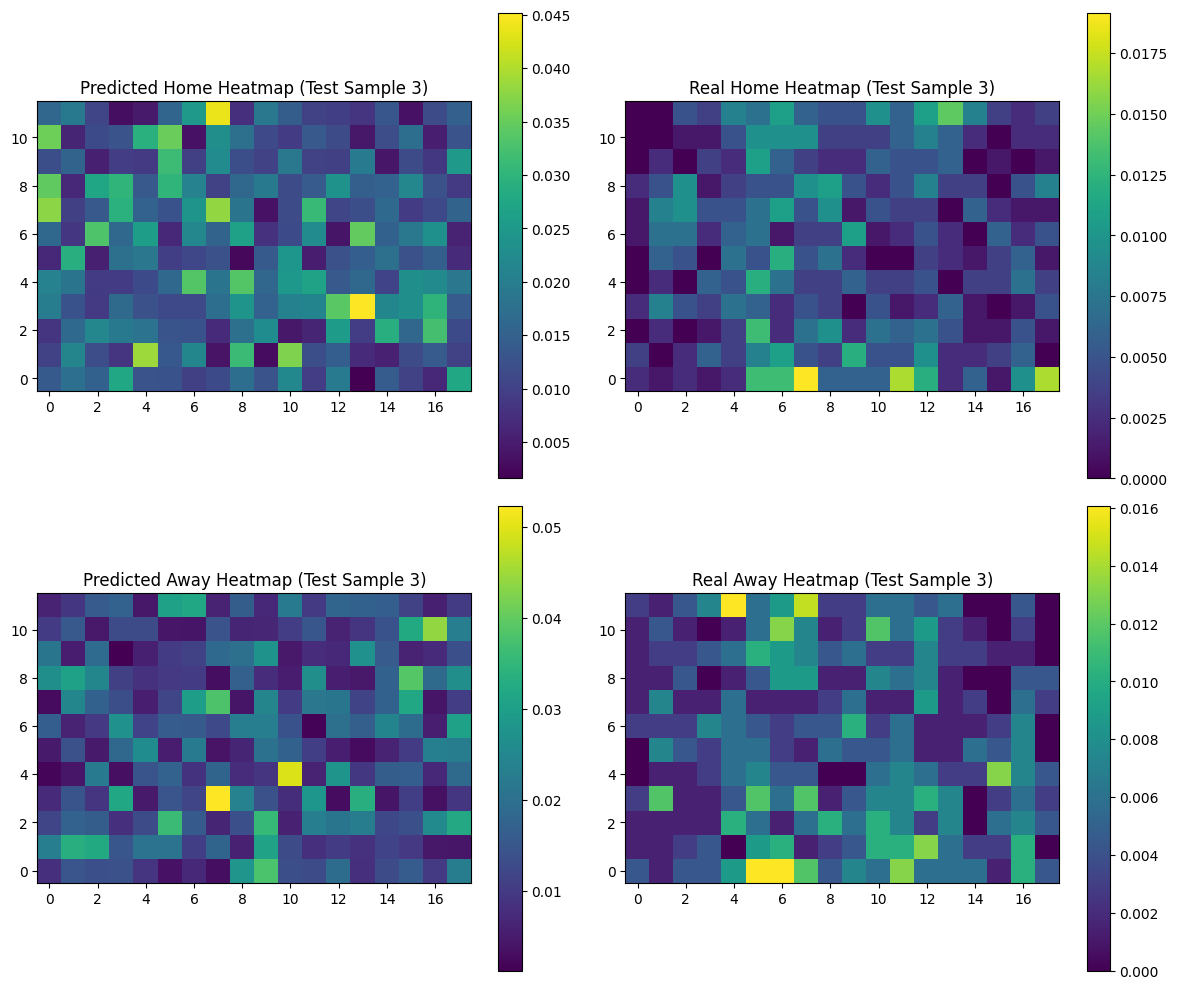

In [18]:
import matplotlib.pyplot as plt

test_ind = 3  # Choose the index of the test sample to visualize

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: Predicted Home Heatmap.
im0 = axes[0, 0].imshow(all_home_preds[test_ind].squeeze(), cmap='viridis', origin='lower')
axes[0, 0].set_title(f"Predicted Home Heatmap (Test Sample {test_ind})")
fig.colorbar(im0, ax=axes[0, 0])

# Top-right: Real Home Heatmap.
im1 = axes[0, 1].imshow(all_home_gt[test_ind].squeeze(), cmap='viridis', origin='lower')
axes[0, 1].set_title(f"Real Home Heatmap (Test Sample {test_ind})")
fig.colorbar(im1, ax=axes[0, 1])

# Bottom-left: Predicted Away Heatmap.
im2 = axes[1, 0].imshow(all_away_preds[test_ind].squeeze(), cmap='viridis', origin='lower')
axes[1, 0].set_title(f"Predicted Away Heatmap (Test Sample {test_ind})")
fig.colorbar(im2, ax=axes[1, 0])

# Bottom-right: Real Away Heatmap.
im3 = axes[1, 1].imshow(all_away_gt[test_ind].squeeze(), cmap='viridis', origin='lower')
axes[1, 1].set_title(f"Real Away Heatmap (Test Sample {test_ind})")
fig.colorbar(im3, ax=axes[1, 1])

print(all_home_preds[test_ind].sum())
plt.tight_layout()
plt.show()


In [117]:
all_home_gt

tensor([[[0.0000, 0.0000, 0.0054,  ..., 0.0054, 0.0000, 0.0080],
         [0.0027, 0.0013, 0.0013,  ..., 0.0054, 0.0040, 0.0027],
         [0.0000, 0.0013, 0.0027,  ..., 0.0040, 0.0040, 0.0040],
         ...,
         [0.0013, 0.0027, 0.0040,  ..., 0.0027, 0.0000, 0.0000],
         [0.0000, 0.0013, 0.0027,  ..., 0.0054, 0.0054, 0.0013],
         [0.0013, 0.0027, 0.0013,  ..., 0.0067, 0.0054, 0.0054]],

        [[0.0013, 0.0038, 0.0000,  ..., 0.0000, 0.0000, 0.0038],
         [0.0025, 0.0088, 0.0063,  ..., 0.0038, 0.0025, 0.0000],
         [0.0038, 0.0025, 0.0075,  ..., 0.0013, 0.0013, 0.0000],
         ...,
         [0.0000, 0.0025, 0.0025,  ..., 0.0025, 0.0038, 0.0025],
         [0.0000, 0.0000, 0.0013,  ..., 0.0013, 0.0000, 0.0000],
         [0.0000, 0.0013, 0.0050,  ..., 0.0063, 0.0025, 0.0050]],

        [[0.0022, 0.0022, 0.0067,  ..., 0.0000, 0.0000, 0.0067],
         [0.0022, 0.0044, 0.0155,  ..., 0.0022, 0.0022, 0.0000],
         [0.0022, 0.0111, 0.0044,  ..., 0.0000, 0.0022, 0.

In [35]:
def plot_heatmap_histogram(heatmap, bins=50, title="Heatmap Intensity Histogram"):
    """
    Plots a histogram of intensities in a 2D heatmap.
    
    Args:
      heatmap (torch.Tensor or np.ndarray): A 2D tensor/array representing the heatmap.
      bins (int): Number of bins to use in the histogram.
      title (str): Title of the plot.
      
    Returns:
      None.
    """
    # Convert to numpy array if heatmap is a torch tensor.
    if torch.is_tensor(heatmap):
        heatmap_np = heatmap.detach().cpu().numpy().flatten()
    else:
        heatmap_np = np.asarray(heatmap).flatten()
    
    plt.figure(figsize=(8, 5))
    plt.hist(heatmap_np, bins=bins, color='blue', edgecolor='black', alpha=0.7)
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

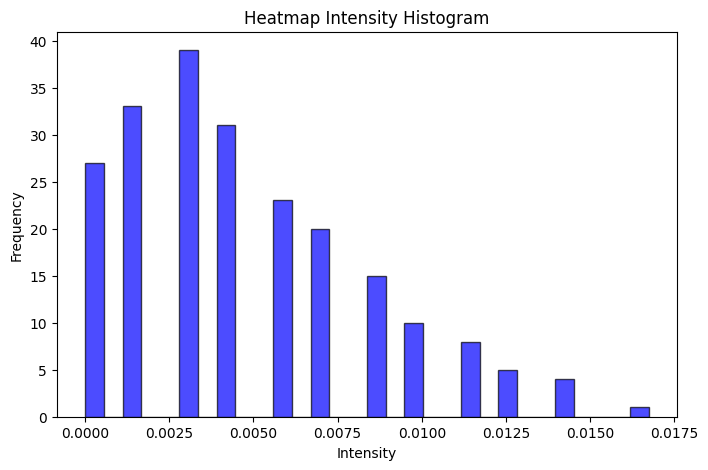

In [58]:
plot_heatmap_histogram(all_home_gt[13], bins=30, title="Heatmap Intensity Histogram")

In [12]:
class BasicHeatmapVAE(nn.Module):
    def __init__(self, n_y, n_x, latent_dim, L=1.0):
        """
        Args:
        n_y (int): Height of each heatmap.
        n_x (int): Width of each heatmap.
        latent_dim (int): Dimension of the latent vector.
        L (float): Maximum intensity value (used to scale the Sigmoid output).
        The model output will be in [0, L].
        """
        super().__init__()
        self.n_y = n_y
        self.n_x = n_x
        self.input_dim = 2 * n_y * n_x
        self.latent_dim = latent_dim
        self.L = L

        # Encoder: map input to a hidden layer then to latent parameters
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder: map latent vector to hidden layer then to output (flattened heatmaps)
        self.fc5 = nn.Linear(latent_dim, 64)
        self.fc6 = nn.Linear(64, 128)
        self.fc7 = nn.Linear(128, 128)
        self.fc8 = nn.Linear(128, 128)
        self.fc_out = nn.Linear(128, self.input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        h3 = F.relu(self.fc3(h2))
        h4 = F.relu(self.fc4(h3))
        mu = self.fc_mu(h4)
        logvar = self.fc_logvar(h4)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h5 = F.relu(self.fc5(z))
        h6 = F.relu(self.fc6(h5))
        h7 = F.relu(self.fc7(h6))
        h8 = F.relu(self.fc8(h7))

        # Use a sigmoid then multiply by L so that the output is in the interval [0, L]
        out = F.relu(self.fc_out(h8))
        return out

    def forward(self, x):
        """
        Args:
        x (torch.Tensor): Input tensor of shape (B, input_dim)
        Returns:
        reconstructed: Tensor of shape (B, input_dim)
        mu (torch.Tensor): Tensor of shape (B, latent_dim)
        logvar (torch.Tensor): Tensor of shape (B, latent_dim)
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

In [9]:
# -----------------------------------------------------------
# Coordinate helpers
# -----------------------------------------------------------
def add_coord_channels(x, with_r=False):
    B, _, H, W = x.shape
    device = x.device

    xx = torch.linspace(-1, 1, W, device=device).view(1, 1, 1, W).expand(B, 1, H, W)
    yy = torch.linspace(-1, 1, H, device=device).view(1, 1, H, 1).expand(B, 1, H, W)
    extra = [xx, yy]
    if with_r:
        rr = torch.sqrt(xx * xx + yy * yy)
        extra.append(rr)
    return torch.cat([x, *extra], dim=1)                # (B,C+2(+1),H,W)

# -----------------------------------------------------------
class CoordConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, *args, with_r=False, **kw):
        super().__init__()
        self.with_r = with_r
        self.conv = nn.Conv2d(in_ch + 2 + int(with_r), out_ch, *args, **kw)

    def forward(self, x):
        return self.conv(add_coord_channels(x, self.with_r))

class CoordConvTranspose2d(nn.Module):
    def __init__(self, in_ch, out_ch, *args, with_r=False, **kw):
        super().__init__()
        self.with_r = with_r
        self.tconv = nn.ConvTranspose2d(in_ch + 2 + int(with_r), out_ch, *args, **kw)

    def forward(self, x):
        return self.tconv(add_coord_channels(x, self.with_r))

# -----------------------------------------------------------
# Encoder CNN (1-channel input  →  cnn_dim vector)
# -----------------------------------------------------------
class SimpleCoordCNN(nn.Module):
    """
    Sequential list of (coord conv → activation → downsample).
    Pass `layer_cfg` as list of dicts, each dict tells:
        {'out':16, 'ks':3, 'pad':1, 'pool':2}
      meaning: CoordConv2d(in_ch, 16, kernel_size=3, padding=1) then AvgPool2d(2)
    """
    def __init__(self, in_ch: int, n_y: int, n_x: int,
                 layer_cfg, out_dim: int):
        super().__init__()
        layers = []
        ch = in_ch
        for cfg in layer_cfg:
            layers.append(CoordConv2d(ch, cfg['out'],
                                      kernel_size=cfg.get('ks',3),
                                      padding=cfg.get('pad',1)))
            layers.append(nn.ReLU(inplace=True))
            if cfg.get('pool', 1) > 1:
                layers.append(nn.AvgPool2d(cfg['pool']))
            ch = cfg['out']
        self.conv = nn.Sequential(*layers)

        # infer flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, n_y, n_x)
            flat_dim = self.conv(dummy).numel()
        self.fc = nn.Linear(flat_dim, out_dim)

    def forward(self, x):                       # (B,1,H,W)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)                       # (B,out_dim)

# -----------------------------------------------------------
# Decoder that upsamples until it meets / exceeds target size,
# then centre-crops or bilinear-resizes back to exact (n_y,n_x)
# -----------------------------------------------------------
class FlexibleCoordDecoder(nn.Module):
    """
    Provide a list of up-blocks.  Each block:
        {'out':32, 'ks':4, 'stride':2, 'pad':1}
    grows H,W by `stride`.  We keep adding blocks until spatial size
    ≥ target, then final 1×1 conv → 1 channel.
    """
    def __init__(self, latent_dim, cond_dim,
                 n_y, n_x,
                 seed_ch=64, seed_h=None, seed_w=None,
                 up_cfg=None):
        super().__init__()
        self.n_y, self.n_x = n_y, n_x

        # pick a default seed if none given:   roughly 1/8 of input
        if seed_h is None: seed_h = max(1, n_y // 8)
        if seed_w is None: seed_w = max(1, n_x // 8)

        self.seed_ch, self.seed_h, self.seed_w = seed_ch, seed_h, seed_w
        self.fc = nn.Linear(latent_dim + cond_dim,
                            seed_ch * seed_h * seed_w)

        if up_cfg is None:
            up_cfg = [
                {'out':seed_ch//2, 'ks':4, 'stride':2, 'pad':1},
                {'out':seed_ch//4, 'ks':4, 'stride':2, 'pad':1},
                {'out':seed_ch//8, 'ks':4, 'stride':2, 'pad':1},
            ]

        up_layers = []
        ch = seed_ch
        cur_h, cur_w = seed_h, seed_w
        for cfg in up_cfg:
            up_layers.append(CoordConvTranspose2d(ch, cfg['out'],
                                                  kernel_size=cfg['ks'],
                                                  stride=cfg['stride'],
                                                  padding=cfg['pad']))
            up_layers.append(nn.ReLU(inplace=True))
            ch = cfg['out']
            cur_h *= cfg['stride']
            cur_w *= cfg['stride']
            if cur_h >= n_y and cur_w >= n_x:
                break            # enough resolution
        self.up = nn.Sequential(*up_layers)
        self.final = nn.Conv2d(ch, 1, kernel_size=1)

    def forward(self, z, cond):                # (B,·)
        B = z.size(0)
        h = torch.cat([z, cond], dim=1)
        h = self.fc(h).view(B, self.seed_ch, self.seed_h, self.seed_w)
        h = self.up(h)                         # upsampled, maybe larger than target
        h = self.final(h)                      # (B,1,H',W')
        h = torch.sigmoid(h)

        # resize / crop back to (n_y,n_x)
        if h.size(2) != self.n_y or h.size(3) != self.n_x:
            h = F.interpolate(h, size=(self.n_y, self.n_x),
                              mode='bilinear', align_corners=False)
        return h

class ConvEnhancedHeatmapVAE(nn.Module):
    def __init__(self, n_y, n_x,
                 latent_dim=128,
                 cnn_dim=128,
                 cond_dim=0):
        super().__init__()
        # Encoder
        enc_cfg = [
            {'out':16, 'ks':2, 'pad':1, 'pool':2},  # H/2
            {'out':32, 'ks':2, 'pad':1, 'pool':2},  # H/4
            {'out':64, 'ks':2, 'pad':1, 'pool':2},  # H/8
        ]
        self.cnn_enc = SimpleCoordCNN(1, n_y, n_x,
                                      layer_cfg=enc_cfg,
                                      out_dim=cnn_dim)

        self.enc_mlp = nn.Sequential(
            nn.Linear(n_y*n_x + cnn_dim + cond_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True)
        )
        self.mu     = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.decoder = FlexibleCoordDecoder(latent_dim, cond_dim,
                                            n_y, n_x,
                                            seed_ch=64)

    def encode(self, x, cond):
        flat = x.flatten(1)             # (B,H*W)
        feat = self.cnn_enc(x)          # (B,cnn_dim)
        h = self.enc_mlp(torch.cat([flat, feat, cond], dim=1))
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5*logvar)

    def forward(self, x, cond=None):
        if cond is None:
            cond = x.new_zeros((x.size(0), 0))  # empty conditioning
        mu, logvar = self.encode(x, cond)
        z = self.reparam(mu, logvar)
        recon = self.decoder(z, cond)          # (B,1,n_y,n_x)
        return recon, mu, logvar

In [10]:
# Suppose our heatmap for each team has size 18 x 12.
n_x, n_y = 18, 12
latent_dim = 128

# Instantiate the model.
model = ConvEnhancedHeatmapVAE(n_y, n_x, latent_dim)


In [80]:
# Loss function with an extra normalization penalty.
def vae_loss(x, x_recon, mu, logvar, norm_weight=2.0):
    """
    Computes the VAE loss comprising:
    1. Reconstruction loss (MSE).
    2. KL divergence.
    3. A normalization penalty that encourages each channel of the reconstructed heatmaps to sum to 1.
    
    Args:
    x (torch.Tensor): Original input, shape (B, input_dim)
    x_recon (torch.Tensor): Reconstructed input, shape (B, input_dim)
    mu, logvar (torch.Tensor): Latent parameters, each of shape (B, latent_dim)
    norm_weight (float): Weight for the normalization penalty term.
    Returns:
    total_loss (torch.Tensor), recon_loss, kl_loss, norm_loss (scalars)
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    
    # KL divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Normalization loss: reshape x_recon to (B, 2, n_y, n_x) and enforce sum over each channel equals 1.
    B = x_recon.size(0)
    # Assume the input was concatenated as [home_flat, away_flat]
    n_pixels = x_recon.size(1) // 2
    recon_reshaped = x_recon.view(B, 2, -1)  # shape: (B, 2, n_y*n_x)
    # Sum over spatial dims, result shape: (B, 2)
    channel_sums = recon_reshaped.sum(dim=2)
    # We want each channel sum to be 1. Compute MSE between channel_sums and ones.
    ones = torch.ones_like(channel_sums)
    norm_loss = F.l1_loss(channel_sums, ones, reduction='sum')
    
    total_loss = recon_loss + kl_loss# + norm_weight * norm_loss
    return total_loss, recon_loss, kl_loss, norm_loss

# -----------------------------
# Training loop
def train_vae(model, train_loader, val_loader, num_epochs, device, norm_weight=1.0, patience=5, scheduler_patience=2):
    """
    Trains the VAE model with a learning rate scheduler and early stopping.
    Uses ReduceLROnPlateau as scheduler.
    
    Args:
    model (nn.Module): The BasicHeatmapVAE.
    train_loader, val_loader: DataLoader objects that yield input tensors of shape (B, input_dim).
    num_epochs (int): Maximum number of epochs.
    device: torch.device.
    norm_weight (float): Weight for the normalization penalty.
    patience (int): Early stopping patience.
    scheduler_patience (int): Learning rate scheduler patience.
    Returns:
    best_model (nn.Module), history (dict with train and val losses)
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, verbose=True)
    
    best_val_loss = np.inf
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        running_norm = 0.0
        
        for batch in train_loader:
            # batch is assumed to be a tuple where the first element is the input tensor of shape (B, input_dim)
            # For our VAE, the target is the same as the input.
            team_player_tensor = batch['home_team_player_heatmap_sequence'][:,-1,:,:]
            away_player_tensor = torch.flip(batch['away_team_player_heatmap_sequence'][:,-1,:,:], dims=(1,2))
            team_player_flat = team_player_tensor.view(-1, n_y * n_x)
            away_player_flat = away_player_tensor.view(-1, n_y * n_x)
            x = torch.cat((team_player_flat, away_player_flat), dim=0)
            x = x.to(device)
            cond = torch.zeros(x.size(0), 0, device=x.device)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x, cond)
            loss, recon_loss, kl_loss, norm_loss = vae_loss(x, x_recon, mu, logvar, norm_weight=norm_weight)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()
            running_norm += norm_loss.item()
        avg_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for batch in val_loader:
                team_player_tensor = batch['home_team_player_heatmap_sequence'][:,-1,:,:]
                away_player_tensor = torch.flip(batch['away_team_player_heatmap_sequence'][:,-1,:,:], dims=(1,2))
                team_player_flat = team_player_tensor.view(-1, n_y * n_x)
                away_player_flat = away_player_tensor.view(-1, n_y * n_x)
                x = torch.cat((team_player_flat, away_player_flat), dim=1)
                x = x.to(device)
                x_recon, mu, logvar = model(x)
                loss, _, _, _ = vae_loss(x, x_recon, mu, logvar, norm_weight=norm_weight)
                running_val += loss.item()
        avg_val_loss = running_val / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)
        
        # Early stopping check.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.show()
    
    history = {"train_losses": train_losses, "val_losses": val_losses}
    return model, history

def visualize_test_samples(model, test_loader, n_y, n_x, num_samples=4, device=torch.device("cpu")):
    """
    Visualizes some test samples from a test DataLoader.
    
    Assumes that the model takes as input a tensor of shape (B, 2*n_y*n_x) (i.e. two concatenated flattened heatmaps)
    and outputs a tensor of the same shape. For each sample, the first half corresponds to the home heatmap
    and the second half to the away heatmap.
    
    The function displays a 2x2 grid for each sample:
    Top-left: Predicted Home Heatmap.
    Top-right: Real Home Heatmap.
    Bottom-left: Predicted Away Heatmap.
    Bottom-right: Real Away Heatmap.
    
    Args:
    model (nn.Module): Trained model.
    test_loader (DataLoader): Yields test inputs (shape: (B, 2*n_y*n_x)).
    n_y (int): Height of each heatmap.
    n_x (int): Width of each heatmap.
    num_samples (int): Number of test samples to visualize.
    device (torch.device): Device for inference.
    """
    model.to(device)
    model.eval()
    
    # Collect one batch from the test_loader.
    # (If your test_loader has many batches, you can iterate over them as needed.)
    with torch.no_grad():
        for batch in test_loader:
            # Assuming each batch is a tuple with one tensor.
            team_player_tensor = batch['home_team_player_heatmap_sequence'][:,-1,:,:]
            away_player_tensor = batch['away_team_player_heatmap_sequence'][:,-1,:,:]
            team_player_flat = team_player_tensor.view(-1, n_y * n_x)
            away_player_flat = away_player_tensor.view(-1, n_y * n_x)
            inputs = torch.cat((team_player_flat, away_player_flat), dim=1)
            inputs = inputs.to(device)
            outputs, mu, logvar = model(inputs)
            # Move to cpu for visualization.
            inputs = inputs.cpu()
            outputs = outputs.cpu()
            break  # Use the first batch only.
    
    # Visualize for the first num_samples in this batch.
    for i in range(min(num_samples, inputs.size(0))):
        # Extract the i-th sample.
        sample_input = inputs[i]          # shape: (2*n_y*n_x,)
        sample_output = outputs[i]          # shape: (2*n_y*n_x,)
        
        # Split into home and away.
        home_input = sample_input[:n_y*n_x].view(n_y, n_x)
        away_input = sample_input[n_y*n_x:].view(n_y, n_x)
        home_output = sample_output[:n_y*n_x].view(n_y, n_x)
        away_output = sample_output[n_y*n_x:].view(n_y, n_x)
        
        # Prints normalization
        print('home_total_mass', torch.sum(home_output))
        print('away_total_mass', torch.sum(away_output))
        # Create a 2x2 figure.
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        im0 = axes[0, 0].imshow(home_output.numpy(), cmap='viridis', origin='lower')
        axes[0, 0].set_title(f"Predicted Home Heatmap (Sample {i})")
        fig.colorbar(im0, ax=axes[0, 0])
        
        im1 = axes[0, 1].imshow(home_input.numpy(), cmap='viridis', origin='lower')
        axes[0, 1].set_title(f"Real Home Heatmap (Sample {i})")
        fig.colorbar(im1, ax=axes[0, 1])
        
        im2 = axes[1, 0].imshow(away_output.numpy(), cmap='viridis', origin='lower')
        axes[1, 0].set_title(f"Predicted Away Heatmap (Sample {i})")
        fig.colorbar(im2, ax=axes[1, 0])
        
        im3 = axes[1, 1].imshow(away_input.numpy(), cmap='viridis', origin='lower')
        axes[1, 1].set_title(f"Real Away Heatmap (Sample {i})")
        fig.colorbar(im3, ax=axes[1, 1])
        
        plt.tight_layout()
        plt.show()
        # -----------------------------

In [81]:
# Training loop
def train_cnn_vae(model, train_loader, val_loader, num_epochs, device, norm_weight=1.0, patience=5, scheduler_patience=2):
    """
    Trains the VAE model with a learning rate scheduler and early stopping.
    Uses ReduceLROnPlateau as scheduler.
    
    Args:
    model (nn.Module): The BasicHeatmapVAE.
    train_loader, val_loader: DataLoader objects that yield input tensors of shape (B, input_dim).
    num_epochs (int): Maximum number of epochs.
    device: torch.device.
    norm_weight (float): Weight for the normalization penalty.
    patience (int): Early stopping patience.
    scheduler_patience (int): Learning rate scheduler patience.
    Returns:
    best_model (nn.Module), history (dict with train and val losses)
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, verbose=True)
    
    best_val_loss = np.inf
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        running_norm = 0.0
        
        for batch in train_loader:
            # batch is assumed to be a tuple where the first element is the input tensor of shape (B, input_dim)
            # For our VAE, the target is the same as the input.
            home_player_tensor = 100*batch['home_team_player_heatmap_sequence'][:,-1,:,:].unsqueeze(1)
            away_player_tensor = torch.flip(100*batch['away_team_player_heatmap_sequence'][:,-1,:,:], dims=(1,2)).unsqueeze(1)
            home_player_tensor = home_player_tensor.to(device)
            away_player_tensor = away_player_tensor.to(device)

            x = torch.cat((home_player_tensor, away_player_tensor), dim=0)
            cond  = torch.zeros(x.size(0), 0, device=x.device)   # no extra cond
            x = x.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x, cond)
            loss, recon_loss, kl_loss, norm_loss = vae_loss(x, x_recon, mu, logvar, norm_weight=norm_weight)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()
            running_norm += norm_loss.item()
        avg_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for batch in val_loader:
                home_player_tensor = 100*batch['home_team_player_heatmap_sequence'][:,-1,:,:].unsqueeze(1)
                away_player_tensor = torch.flip(100*batch['away_team_player_heatmap_sequence'][:,-1,:,:], dims=(1,2)).unsqueeze(1)
                home_player_tensor = home_player_tensor.to(device)
                away_player_tensor = away_player_tensor.to(device)

                x = torch.cat((home_player_tensor, away_player_tensor), dim=0)
                cond  = torch.zeros(x.size(0), 0, device=x.device)   # no extra cond
                x = x.to(device)
                x_recon, mu, logvar = model(x, cond)
                loss, _, _, _ = vae_loss(x, x_recon, mu, logvar, norm_weight=norm_weight)
                running_val += loss.item()
        avg_val_loss = running_val / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)
        
        # Early stopping check.
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.show()
    
    history = {"train_losses": train_losses, "val_losses": val_losses}
    return model, history

# -----------------------------------------------------------
def visualize_test_samples(model,
                           test_loader,
                           n_y: int,
                           n_x: int,
                           num_samples: int = 4,
                           device: torch.device = torch.device("cpu")):
    """
    Visualise `num_samples` test items (home & away heat-maps) in a 2×2 grid:
        ┌──────────────────────┬──────────────────────┐
        │  pred home           │  real home           │
        ├──────────────────────┼──────────────────────┤
        │  pred away           │  real away           │
        └──────────────────────┴──────────────────────┘
    The model must accept a tensor (B,1,H,W) and return
        recon, mu, logvar   with recon shape (B,1,H,W).
    """
    model = model.to(device).eval()

    # ---------- fetch one batch ----------
    with torch.no_grad():
        batch = next(iter(test_loader))

        #   (B, M, H, W)  →  last match  →  (B, H, W)
        real_home = batch['home_team_player_heatmap_sequence'][:, -1, :, :]
        real_away = batch['away_team_player_heatmap_sequence'][:, -1, :, :]

        # If in your pipeline away maps need flipping to the same orientation, do it here:
        real_away = torch.flip(real_away, dims=[1, 2])

        # (B,1,H,W) on device
        home_in = real_home.unsqueeze(1).to(device)
        away_in = real_away.unsqueeze(1).to(device)

        # run the model twice (no conditioning vector)
        home_pred, _, _ = model(home_in)        # (B,1,H,W)
        away_pred, _, _ = model(away_in)        # (B,1,H,W)

        # bring everything to CPU for plotting
        home_pred = 0.01*home_pred.squeeze(1).cpu()
        away_pred = 0.01*away_pred.squeeze(1).cpu()
        real_home = real_home.cpu()
        real_away = real_away.cpu()

    # ---------- plot ----------
    ns = min(num_samples, home_pred.size(0))
    for i in range(ns):
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))

        im0 = axes[0, 0].imshow(home_pred[i], cmap='viridis', origin='lower')
        axes[0, 0].set_title(f"Predicted Home  (#{i})")
        fig.colorbar(im0, ax=axes[0, 0])

        im1 = axes[0, 1].imshow(real_home[i], cmap='viridis', origin='lower')
        axes[0, 1].set_title(f"Real Home  (#{i})")
        fig.colorbar(im1, ax=axes[0, 1])

        im2 = axes[1, 0].imshow(away_pred[i], cmap='viridis', origin='lower')
        axes[1, 0].set_title(f"Predicted Away  (#{i})")
        fig.colorbar(im2, ax=axes[1, 0])

        im3 = axes[1, 1].imshow(real_away[i], cmap='viridis', origin='lower')
        axes[1, 1].set_title(f"Real Away  (#{i})")
        fig.colorbar(im3, ax=axes[1, 1])

        plt.tight_layout()
        plt.show()


In [11]:
# -----------------------------------------------------------
# 1. Loss   --------------------------------------------------
def vae_loss(x,
             x_recon,
             mu,
             logvar,
             kl_weight: float = 1.0,
             norm_weight: float = 2.0):
    """
    total = recon  +  kl_weight * KL  +  norm_weight * L1-normalisation
    - recon  : summed MSE
    - KL     : classic closed form
    - norm   : L1 between Σ(recon_channel) and 1
    """
    B = x.size(0)
    # --- reconstruction ---
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')

    # --- KL divergence ---
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # --- channel-normalisation ---
    n_pixels = x_recon.size(1) // 2                      # we concatenated home|away
    recon_reshaped = x_recon.view(B, 2, -1)              # (B,2,n_pix)
    channel_sums   = recon_reshaped.sum(dim=2)           # (B,2)
    norm_loss      = F.l1_loss(channel_sums,
                               torch.ones_like(channel_sums),
                               reduction='sum')

    total = recon_loss + kl_weight * kl_loss + norm_weight * norm_loss
    return total, recon_loss, kl_loss, norm_loss

# -----------------------------------------------------------
# 2. Training with KL-anneal  -------------------------------
def train_cnn_vae_anneal(model,
                         train_loader,
                         val_loader,
                         num_epochs: int,
                         device,
                         kl_anneal_epochs: int = 10,
                         norm_weight: float = 2.0,
                         lr: float = 1e-4,
                         patience: int = 5,
                         scheduler_patience: int = 2):
    """
    - *kl_anneal_epochs*: epochs for the KL weight to ramp from 0 → 1.
    """
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                 patience=scheduler_patience,
                                                 verbose=True)

    best_val = math.inf
    best_state = None
    no_improve = 0
    train_hist, val_hist = [], []

    for epoch in range(1, num_epochs + 1):
        # ---------- training ----------
        model.train()
        kl_w = min(1.0, epoch / kl_anneal_epochs)   # linear ramp
        train_sum = 0.0

        for batch in train_loader:
            home = 100 * batch['home_team_player_heatmap_sequence'][:, -1].unsqueeze(1)
            away = 100 * torch.flip(
                       batch['away_team_player_heatmap_sequence'][:, -1], dims=[1, 2]
                   ).unsqueeze(1)

            x = torch.cat([home, away], dim=0).to(device)  # (B_tot,1,H,W)
            cond = torch.zeros(x.size(0), 0, device=device)

            opt.zero_grad()
            recon, mu, logvar = model(x, cond)
            loss, *_ = vae_loss(x, recon, mu, logvar,
                                kl_weight=kl_w,
                                norm_weight=norm_weight)
            loss.backward()
            opt.step()
            train_sum += loss.item()

        train_loss = train_sum / len(train_loader.dataset)
        train_hist.append(train_loss)

        # ---------- validation ----------
        model.eval()
        val_sum = 0.0
        with torch.no_grad():
            for batch in val_loader:
                home = 100 * batch['home_team_player_heatmap_sequence'][:, -1].unsqueeze(1)
                away = 100 * torch.flip(
                           batch['away_team_player_heatmap_sequence'][:, -1], dims=[1, 2]
                       ).unsqueeze(1)
                x = torch.cat([home, away], dim=0).to(device)
                cond = torch.zeros(x.size(0), 0, device=device)
                recon, mu, logvar = model(x, cond)
                loss, *_ = vae_loss(x, recon, mu, logvar,
                                    kl_weight=kl_w,
                                    norm_weight=norm_weight)
                val_sum += loss.item()

        val_loss = val_sum / len(val_loader.dataset)
        val_hist.append(val_loss)

        print(f"Epoch {epoch:3d} | KL-w {kl_w:4.2f} | "
              f"train {train_loss:8.4f} | val {val_loss:8.4f}")
        sched.step(val_loss)

        # ---------- early-stop ----------
        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---------- plot ----------
    plt.figure(figsize=(10, 5))
    plt.plot(train_hist, label='train')
    plt.plot(val_hist,   label='val')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

    return model, {'train': train_hist, 'val': val_hist}

In [ ]:
trained_model, history = train_cnn_vae_anneal(
        model,
        train_loader,
        val_loader,
        num_epochs       = 200,
        device           = torch.device('cuda'),
        kl_anneal_epochs = 10,     # warm-up
        norm_weight      = 1.0,
        lr               = 1e-4,
        patience         = 7,
        scheduler_patience = 2
    )

c:\Users\luisi\Documents\Programming\Projects\Transformers\transformers\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | KL-w 0.10 | train 296.3418 | val 295.7817
Epoch   2 | KL-w 0.20 | train 295.5517 | val 294.9866
Epoch   3 | KL-w 0.30 | train 294.7232 | val 294.1281
Epoch   4 | KL-w 0.40 | train 293.8189 | val 293.1719
Epoch   5 | KL-w 0.50 | train 292.7874 | val 292.0386
Epoch   6 | KL-w 0.60 | train 291.5557 | val 290.6848
Epoch   7 | KL-w 0.70 | train 290.0649 | val 289.0348
Epoch   8 | KL-w 0.80 | train 288.2204 | val 286.8956
Epoch   9 | KL-w 0.90 | train 285.8022 | val 283.9882
Epoch  10 | KL-w 1.00 | train 282.4285 | val 279.6949
Epoch  11 | KL-w 1.00 | train 277.0725 | val 272.5781
Epoch  12 | KL-w 1.00 | train 266.9514 | val 257.6841
Epoch  13 | KL-w 1.00 | train 246.9328 | val 232.9733
Epoch  14 | KL-w 1.00 | train 223.7757 | val 213.2131
Epoch  15 | KL-w 1.00 | train 207.8271 | val 201.2940
Epoch  16 | KL-w 1.00 | train 197.9971 | val 194.1934
Epoch  17 | KL-w 1.00 | train 191.5401 | val 188.8353
Epoch  18 | KL-w 1.00 | train 186.9863 | val 185.0227
Epoch  19 | KL-w 1.00 | trai

Epoch 1: Train Loss = 71.7559, Val Loss = 71.5059
Epoch 2: Train Loss = 71.4613, Val Loss = 71.2751
Epoch 3: Train Loss = 71.2498, Val Loss = 71.0814
Epoch 4: Train Loss = 71.0540, Val Loss = 70.8836
Epoch 5: Train Loss = 70.8482, Val Loss = 70.6702
Epoch 6: Train Loss = 70.6249, Val Loss = 70.4417
Epoch 7: Train Loss = 70.3865, Val Loss = 70.1941
Epoch 8: Train Loss = 70.1274, Val Loss = 69.9306
Epoch 9: Train Loss = 69.8570, Val Loss = 69.6513
Epoch 10: Train Loss = 69.5621, Val Loss = 69.3440
Epoch 11: Train Loss = 69.2302, Val Loss = 68.9941
Epoch 12: Train Loss = 68.8405, Val Loss = 68.5866
Epoch 13: Train Loss = 68.3821, Val Loss = 68.0905
Epoch 14: Train Loss = 67.8437, Val Loss = 67.4792
Epoch 15: Train Loss = 67.2106, Val Loss = 66.8264
Epoch 16: Train Loss = 66.4511, Val Loss = 66.0080
Epoch 17: Train Loss = 65.5852, Val Loss = 65.1197
Epoch 18: Train Loss = 64.6555, Val Loss = 64.2189
Epoch 19: Train Loss = 63.6839, Val Loss = 63.1938
Epoch 20: Train Loss = 62.6270, Val Loss

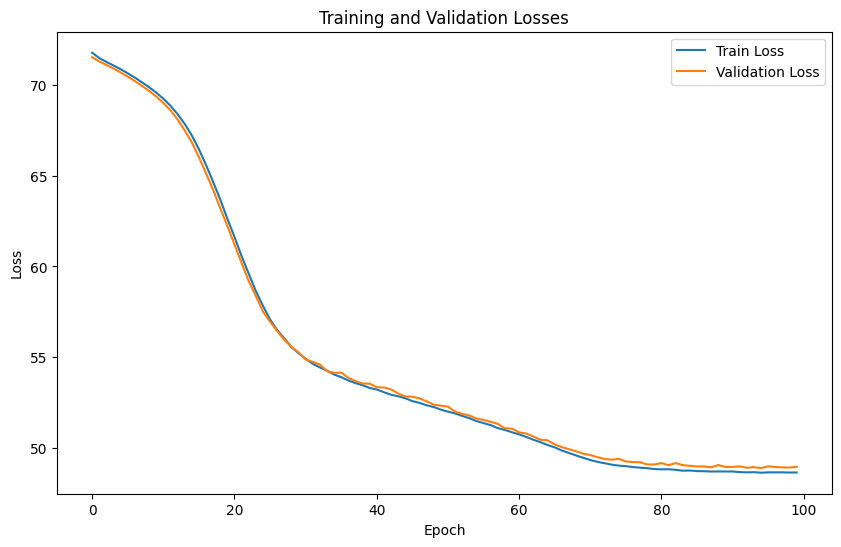

In [82]:
device = 'cuda'
trained_model, history = train_cnn_vae(model, train_loader, val_loader, num_epochs=200,
                            device=device, norm_weight=1.0, patience=5, scheduler_patience=2)

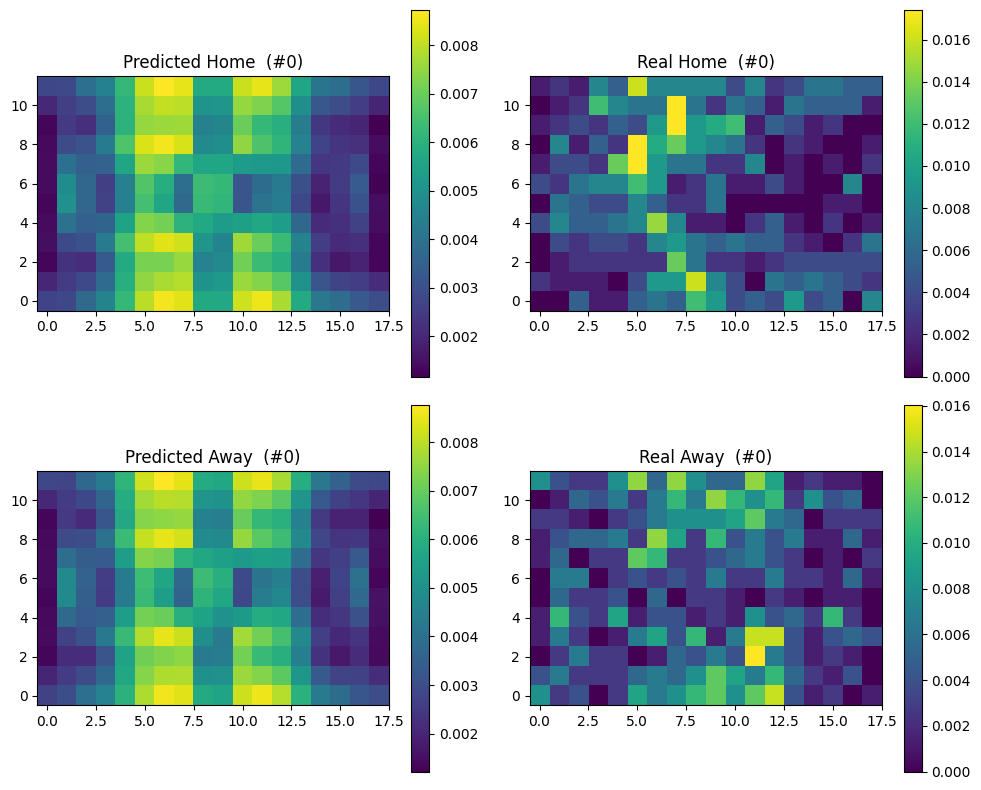

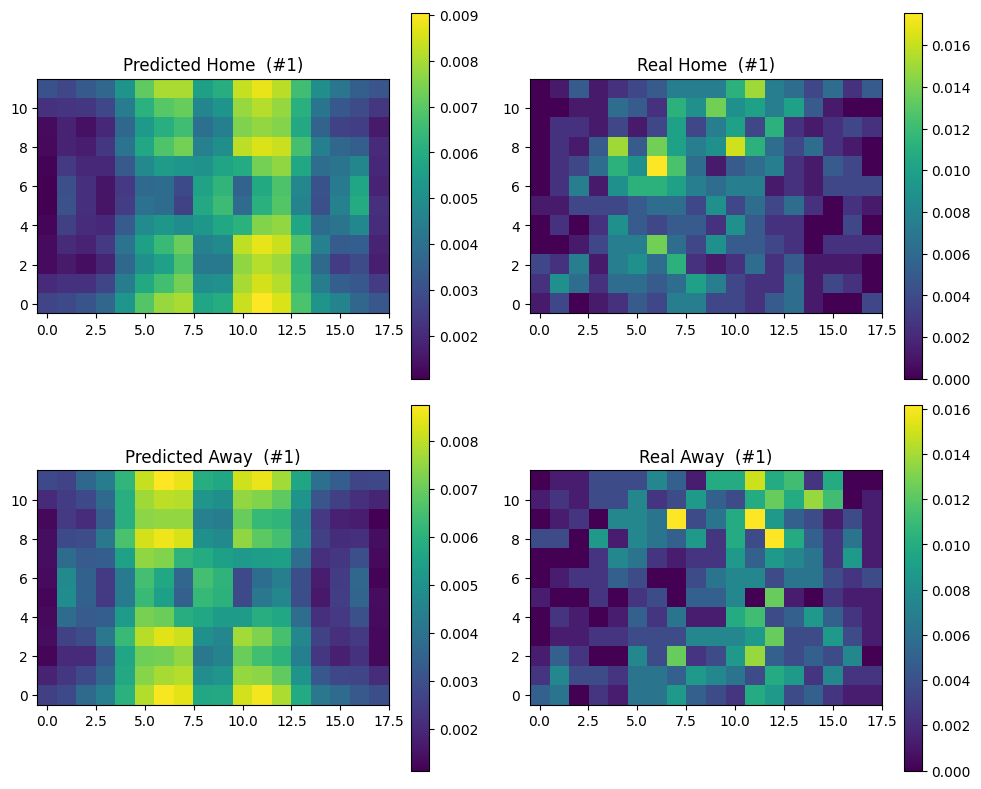

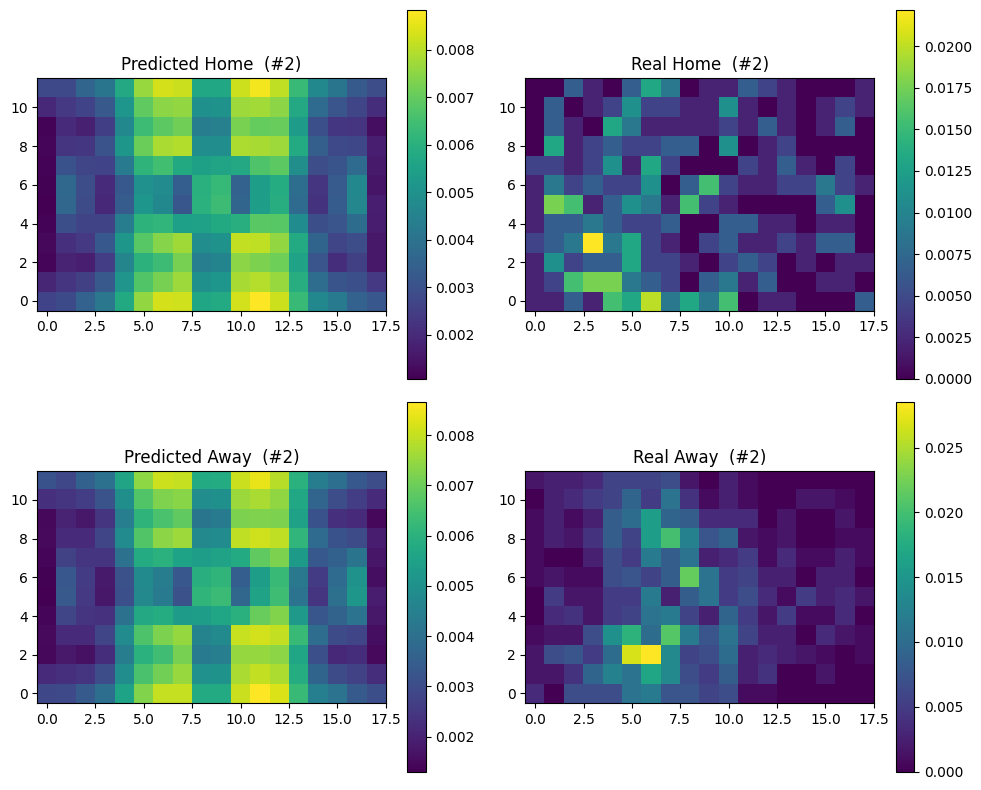

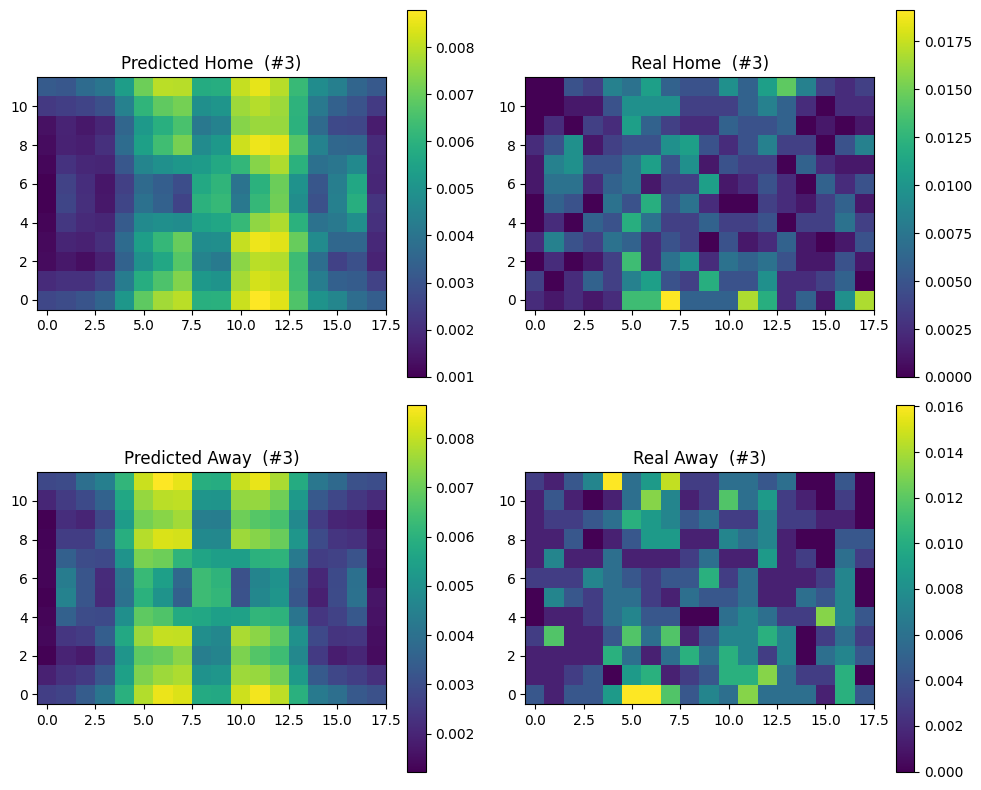

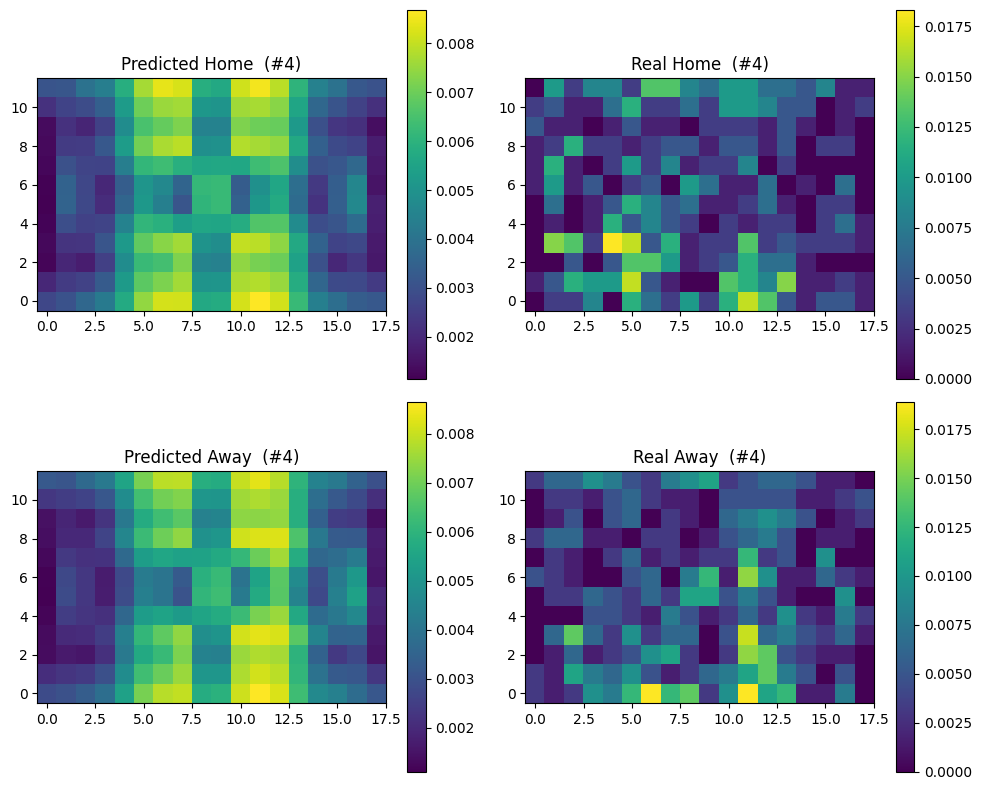

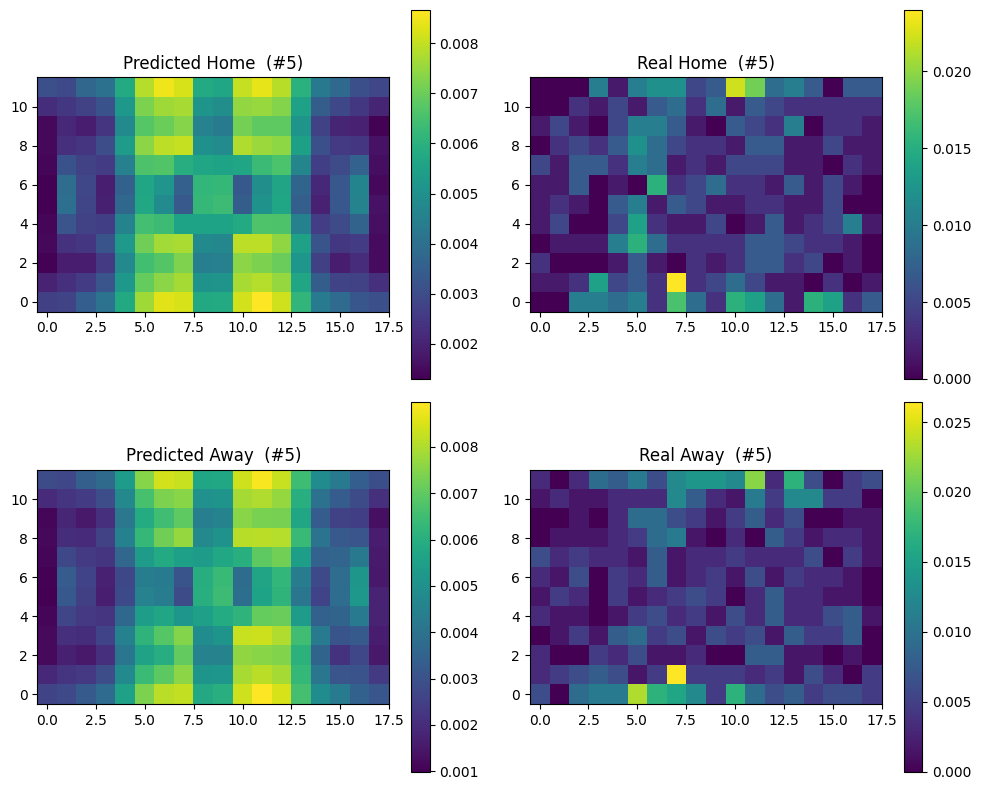

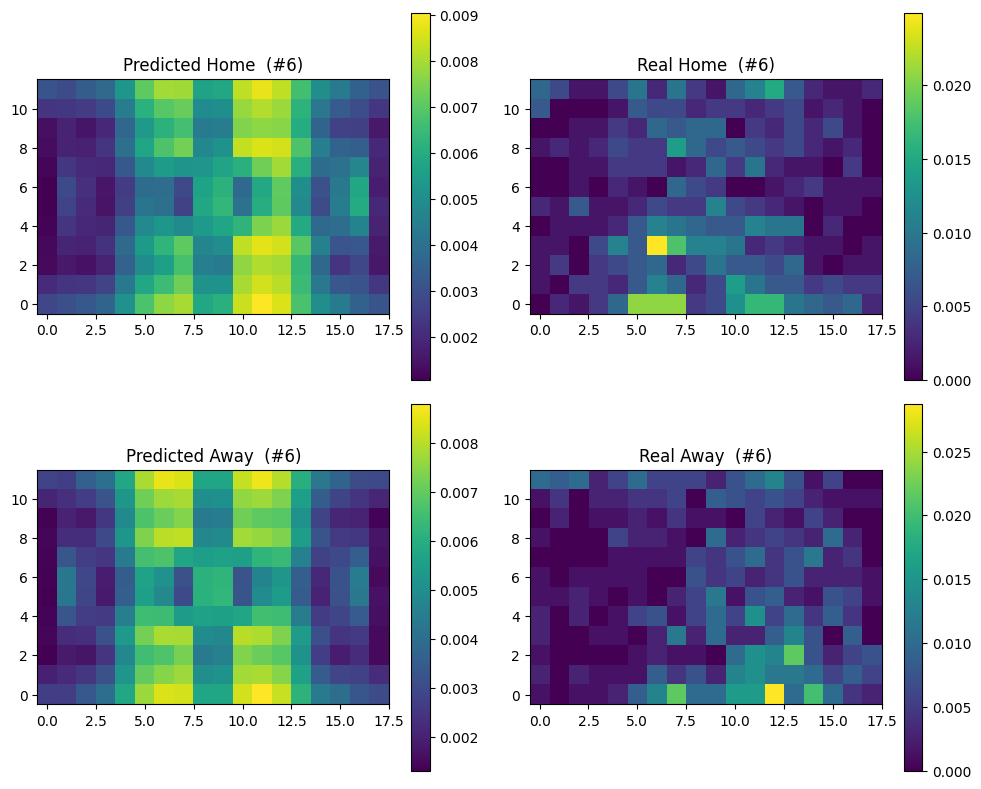

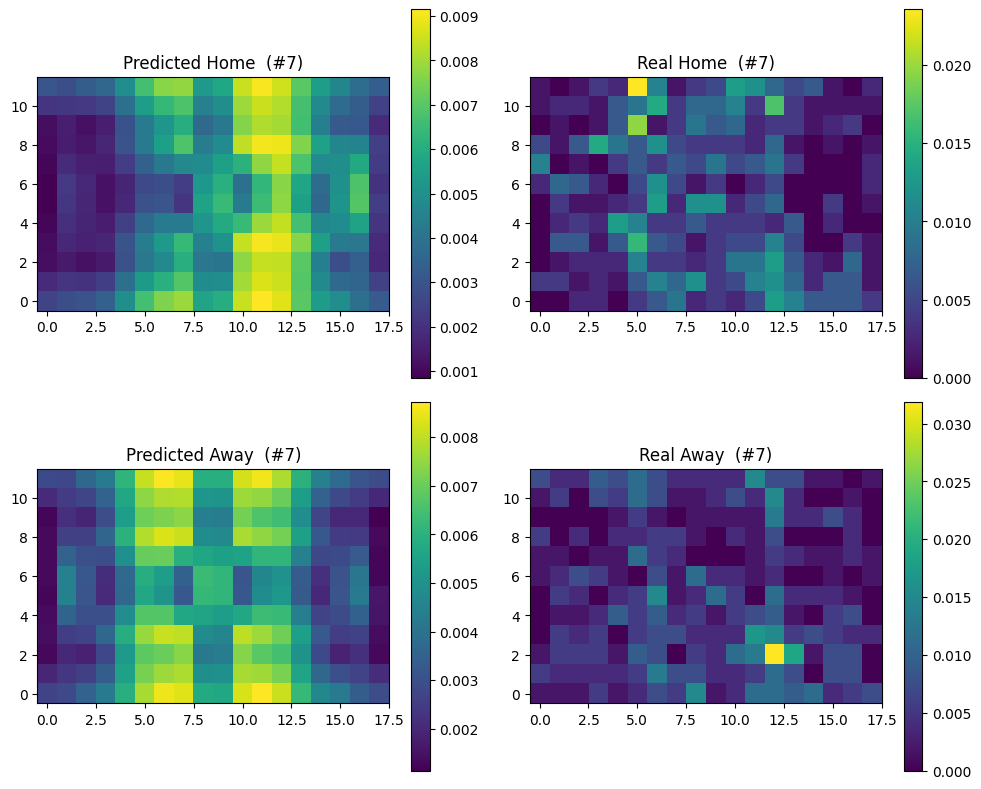

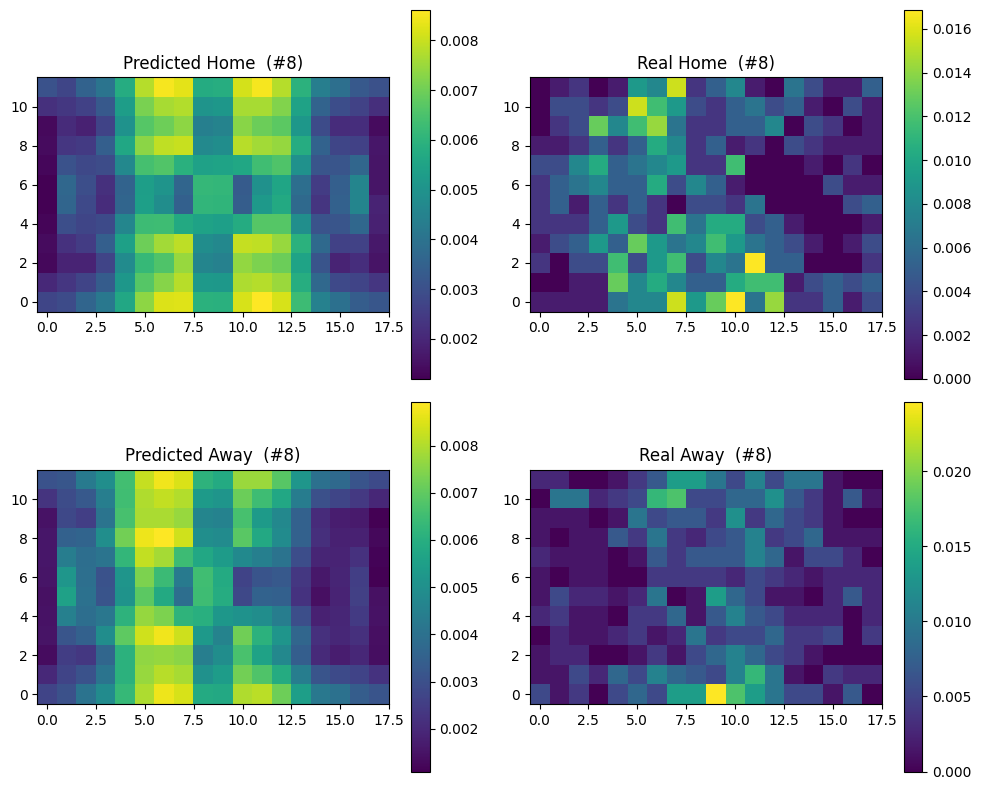

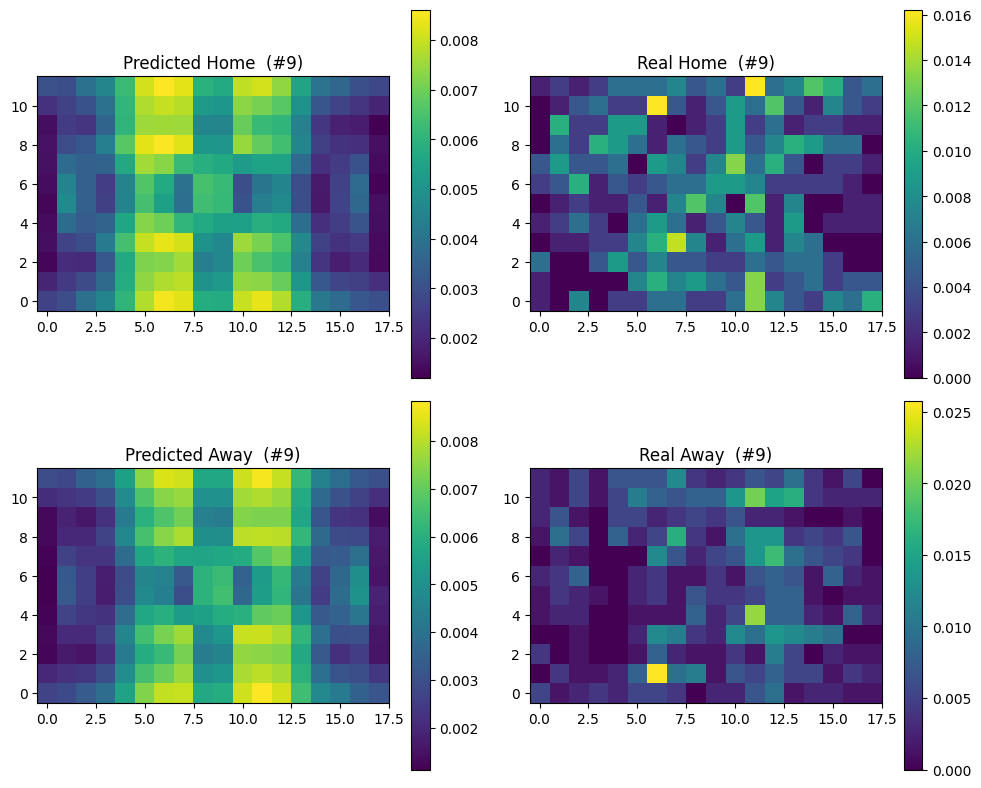

In [83]:
visualize_test_samples(trained_model, test_loader, n_y, n_x, num_samples=10, device=device)